# Assignment 04 — CIFAR-10 CNN: Overfitting Demo and Fixes

Dataset: **CIFAR-10** (60,000 32x32 RGB images, 10 classes). Sourced from public dataset aggregators (DataQuest free-datasets list links to it via Kaggle / TensorFlow).

Goal:
1. Prepare the data and split into train / validation / test
2. Build an **overparameterized CNN** with no regularization → show overfitting
3. Build a **regularized CNN** with **Dropout + L2 + Data Augmentation** → reduce overfitting
4. Compare with 4+ graphs (loss & accuracy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, datasets
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)
print('TF version:', tf.__version__)

TF version: 2.19.0


## 1. Data Preparation

In [2]:
(x_full, y_full), (x_test, y_test) = datasets.cifar10.load_data()
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print('Full train shape:', x_full.shape, 'Test shape:', x_test.shape)

Full train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


C:\Users\ryand\AppData\Local\Temp\ipykernel_38592\1534624834.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_full[i])])


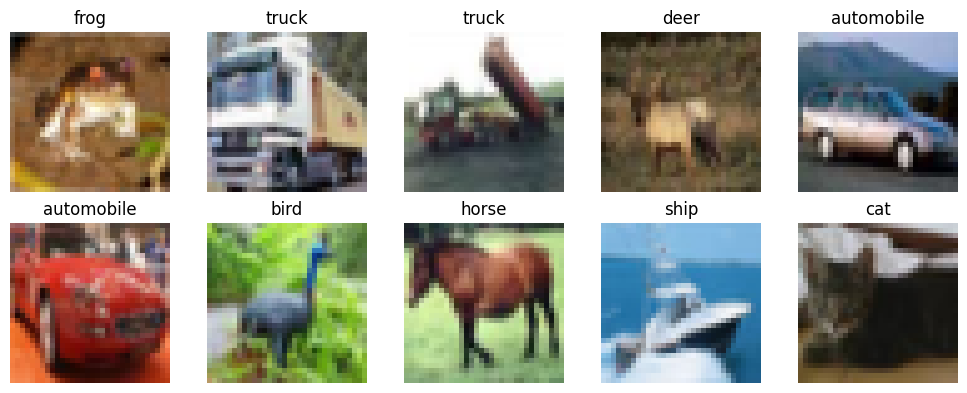

In [3]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_full[i])
    plt.title(class_names[int(y_full[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Train / Validation / Test Split + Normalization

In [4]:
x_full = x_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

val_size = 5000
x_val, y_val = x_full[:val_size], y_full[:val_size]
x_train, y_train = x_full[val_size:], y_full[val_size:]

y_train_oh = to_categorical(y_train, 10)
y_val_oh = to_categorical(y_val, 10)
y_test_oh = to_categorical(y_test, 10)

print('Train:', x_train.shape, '| Val:', x_val.shape, '| Test:', x_test.shape)

Train: (45000, 32, 32, 3) | Val: (5000, 32, 32, 3) | Test: (10000, 32, 32, 3)


## 3. Overparameterized CNN (no regularization) — to expose overfitting

Lots of filters, big dense layer, no dropout, no L2 → the model has way more capacity than needed and will memorize the training set.

In [5]:
def build_overparam_cnn():
    m = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

bad_model = build_overparam_cnn()
bad_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,344,586 (69.98 MB)

 Trainable params: 18,344,586 (69.98 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS_BAD = 20
history_bad = bad_model.fit(
    x_train, y_train_oh,
    validation_data=(x_val, y_val_oh),
    epochs=EPOCHS_BAD,
    batch_size=128,
    verbose=2
)

Epoch 1/20
352/352 - 329s - 935ms/step - accuracy: 0.4397 - loss: 1.5325 - val_accuracy: 0.5934 - val_loss: 1.1485
Epoch 2/20
352/352 - 299s - 850ms/step - accuracy: 0.6676 - loss: 0.9412 - val_accuracy: 0.6992 - val_loss: 0.8536
Epoch 3/20
352/352 - 333s - 946ms/step - accuracy: 0.7547 - loss: 0.7024 - val_accuracy: 0.7146 - val_loss: 0.8230
Epoch 4/20
352/352 - 299s - 849ms/step - accuracy: 0.8111 - loss: 0.5404 - val_accuracy: 0.7038 - val_loss: 0.9218
Epoch 5/20
352/352 - 301s - 856ms/step - accuracy: 0.8612 - loss: 0.4004 - val_accuracy: 0.7140 - val_loss: 1.0250
Epoch 6/20
352/352 - 288s - 819ms/step - accuracy: 0.8995 - loss: 0.2915 - val_accuracy: 0.7320 - val_loss: 1.0314
Epoch 7/20
352/352 - 278s - 790ms/step - accuracy: 0.9288 - loss: 0.2054 - val_accuracy: 0.7274 - val_loss: 1.2043
Epoch 8/20
352/352 - 351s - 998ms/step - accuracy: 0.9496 - loss: 0.1456 - val_accuracy: 0.7414 - val_loss: 1.2882
Epoch 9/20
352/352 - 309s - 878ms/step - accuracy: 0.9674 - loss: 0.0958 - val_a

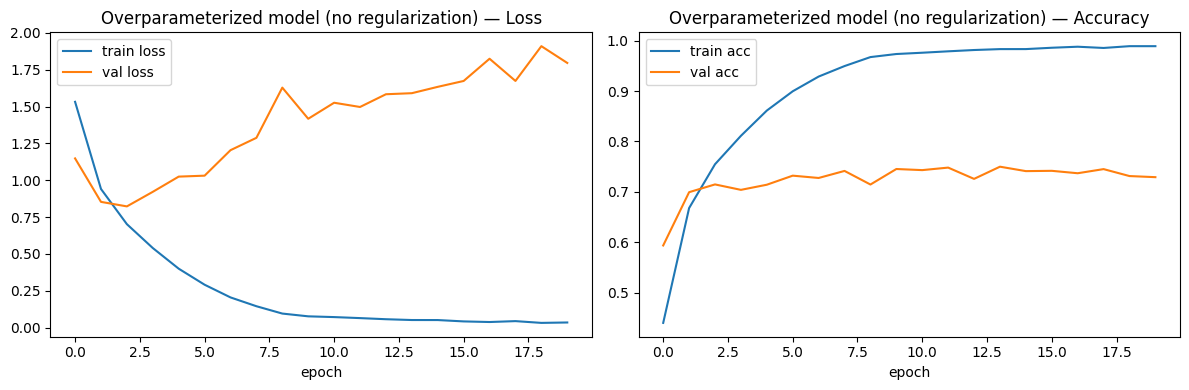

In [7]:
def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(h.history['loss'], label='train loss')
    ax[0].plot(h.history['val_loss'], label='val loss')
    ax[0].set_title(f'{title} — Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(h.history['accuracy'], label='train acc')
    ax[1].plot(h.history['val_accuracy'], label='val acc')
    ax[1].set_title(f'{title} — Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_bad, 'Overparameterized model (no regularization)')

**Observation:** training accuracy keeps climbing toward ~100% while validation accuracy stalls and validation loss starts going **up** → classic overfitting.

## 4. Regularized CNN: Dropout + L2 + Data Augmentation

Three fixes applied at once:
- **Data augmentation** (random flip, rotation, zoom) → exposes the model to more variation
- **L2 regularization** on conv + dense layers → penalizes large weights
- **Dropout** between layers → prevents co-adaptation

In [8]:
data_augment = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def build_regularized_cnn():
    l2 = regularizers.l2(1e-4)
    m = models.Sequential([
        layers.Input(shape=(32,32,3)),
        data_augment,
        layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.35),
        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=l2),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

good_model = build_regularized_cnn()
good_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS_GOOD = 30
history_good = good_model.fit(
    x_train, y_train_oh,
    validation_data=(x_val, y_val_oh),
    epochs=EPOCHS_GOOD,
    batch_size=128,
    verbose=2
)

Epoch 1/30
352/352 - 90s - 255ms/step - accuracy: 0.3408 - loss: 1.8470 - val_accuracy: 0.4648 - val_loss: 1.5324
Epoch 2/30
352/352 - 87s - 246ms/step - accuracy: 0.4694 - loss: 1.5278 - val_accuracy: 0.5406 - val_loss: 1.3508
Epoch 3/30
352/352 - 87s - 249ms/step - accuracy: 0.5166 - loss: 1.4238 - val_accuracy: 0.5886 - val_loss: 1.2516
Epoch 4/30
352/352 - 87s - 246ms/step - accuracy: 0.5521 - loss: 1.3537 - val_accuracy: 0.6366 - val_loss: 1.1669
Epoch 5/30
352/352 - 85s - 242ms/step - accuracy: 0.5737 - loss: 1.3064 - val_accuracy: 0.6624 - val_loss: 1.0891
Epoch 6/30
352/352 - 87s - 247ms/step - accuracy: 0.5886 - loss: 1.2714 - val_accuracy: 0.6732 - val_loss: 1.0338
Epoch 7/30
352/352 - 83s - 236ms/step - accuracy: 0.6088 - loss: 1.2298 - val_accuracy: 0.6872 - val_loss: 1.0334
Epoch 8/30
352/352 - 88s - 249ms/step - accuracy: 0.6209 - loss: 1.2102 - val_accuracy: 0.7088 - val_loss: 0.9680
Epoch 9/30
352/352 - 83s - 237ms/step - accuracy: 0.6306 - loss: 1.1872 - val_accuracy: 

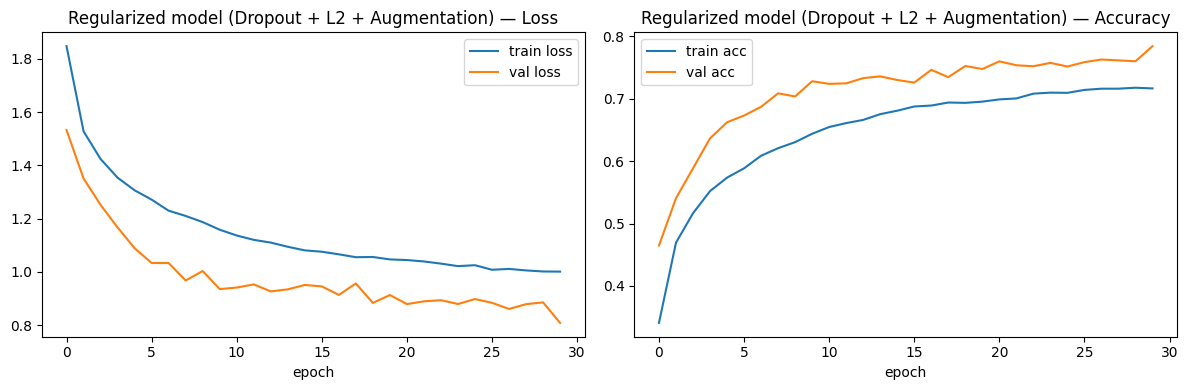

In [10]:
plot_history(history_good, 'Regularized model (Dropout + L2 + Augmentation)')

## 5. Side-by-side Comparison

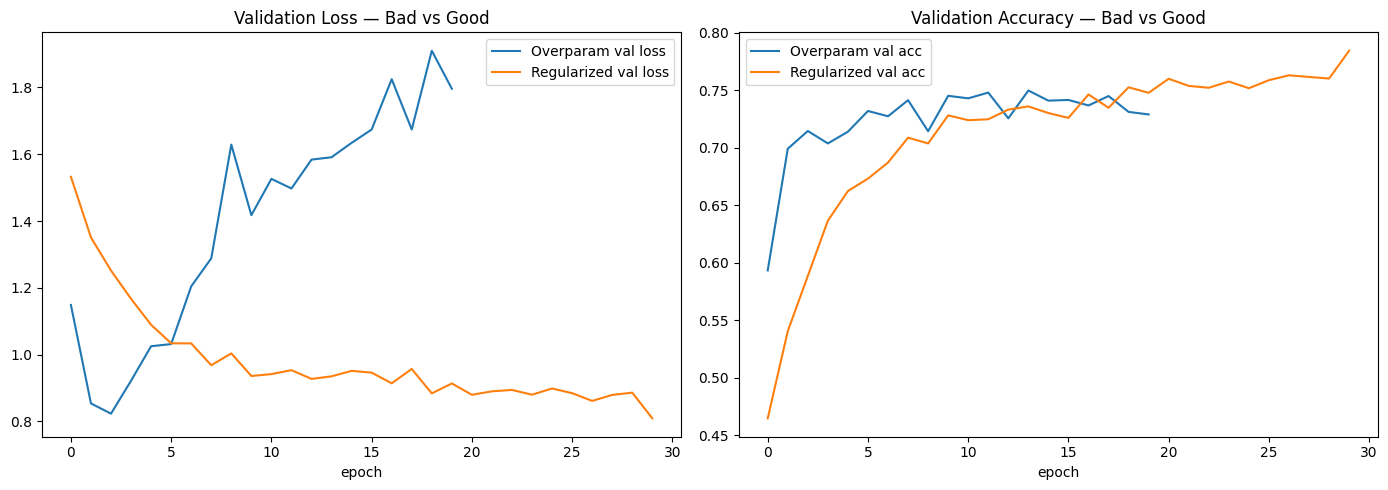

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].plot(history_bad.history['val_loss'], label='Overparam val loss')
ax[0].plot(history_good.history['val_loss'], label='Regularized val loss')
ax[0].set_title('Validation Loss — Bad vs Good'); ax[0].set_xlabel('epoch'); ax[0].legend()

ax[1].plot(history_bad.history['val_accuracy'], label='Overparam val acc')
ax[1].plot(history_good.history['val_accuracy'], label='Regularized val acc')
ax[1].set_title('Validation Accuracy — Bad vs Good'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

In [12]:
def gap(h):
    return h.history['accuracy'][-1] - h.history['val_accuracy'][-1]

print(f"Overparam model — train acc: {history_bad.history['accuracy'][-1]:.3f}, val acc: {history_bad.history['val_accuracy'][-1]:.3f}, gap: {gap(history_bad):.3f}")
print(f"Regularized model — train acc: {history_good.history['accuracy'][-1]:.3f}, val acc: {history_good.history['val_accuracy'][-1]:.3f}, gap: {gap(history_good):.3f}")

Overparam model — train acc: 0.989, val acc: 0.729, gap: 0.260
Regularized model — train acc: 0.717, val acc: 0.784, gap: -0.068


## 6. Final Test-set Evaluation

In [13]:
bad_test = bad_model.evaluate(x_test, y_test_oh, verbose=0)
good_test = good_model.evaluate(x_test, y_test_oh, verbose=0)
print(f'Overparam model  — test loss: {bad_test[0]:.3f}, test acc: {bad_test[1]:.3f}')
print(f'Regularized model — test loss: {good_test[0]:.3f}, test acc: {good_test[1]:.3f}')

Overparam model  — test loss: 1.900, test acc: 0.728
Regularized model — test loss: 0.841, test acc: 0.780


## 7. Conclusion

- The **overparameterized** CNN clearly overfits: high train accuracy, lower validation accuracy, validation loss rising over epochs.
- Adding **Dropout + L2 + Data Augmentation** narrowed the train/val gap and improved test accuracy.
- **Epoch choice:** 20 epochs were enough to expose overfitting in the first model; 30 epochs were needed for the regularized model since augmentation slows convergence.

**Topics covered:** data prep ✓ · train/val/test split ✓ · L2 + Dropout ✓ · overparameterization ✓ · data augmentation ✓ · convnets ✓ · epoch tuning ✓